# 4.1 - Regression Model: Training and Evaluation

## 1: Dependencies and Imports

In [11]:
%pip install kagglehub pandas

Note: you may need to restart the kernel to use updated packages.


In [12]:
# Standard library
import os

# Third-party
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2: Load Data

In [13]:
# Download the Olist Brazilian E-Commerce dataset
dataset_path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print(f"Dataset directory: {dataset_path}")

# List all available CSV files in the directory
files = os.listdir(dataset_path)
print("\nFiles found:")
for file in files:
    print(f"- {file}")

Dataset directory: /Users/sergio/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2

Files found:
- olist_sellers_dataset.csv
- product_category_name_translation.csv
- olist_orders_dataset.csv
- olist_order_items_dataset.csv
- olist_customers_dataset.csv
- olist_geolocation_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_reviews_dataset.csv
- olist_products_dataset.csv


## 3: Data Visualization

In [14]:
# Load all datasets
dataframes = {}
file_list = [
    'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv',
    'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv',
    'olist_order_reviews_dataset.csv', 'olist_orders_dataset.csv',
    'olist_products_dataset.csv', 'olist_sellers_dataset.csv',
    'product_category_name_translation.csv'
]

for file in file_list:
    key = file.replace('.csv', '')
    dataframes[key] = pd.read_csv(os.path.join(dataset_path, file))

# Sequential Data Integration

# A. Orders + Customers (Key: customer_id)
df = pd.merge(dataframes['olist_orders_dataset'], dataframes['olist_customers_dataset'], on='customer_id', how='left')

# B. Incorporate Payments (Key: order_id)
df = pd.merge(df, dataframes['olist_order_payments_dataset'], on='order_id', how='left')

# C. Incorporate Reviews (Key: order_id)
df = pd.merge(df, dataframes['olist_order_reviews_dataset'], on='order_id', how='left')

# D. Incorporate Order Items (Key: order_id)
# Note: This operation may increase row count due to multiple items per order
df = pd.merge(df, dataframes['olist_order_items_dataset'], on='order_id', how='left')

# E. Incorporate Product Details (Key: product_id)
df = pd.merge(df, dataframes['olist_products_dataset'], on='product_id', how='left')

# F. Incorporate Seller Details (Key: seller_id)
df = pd.merge(df, dataframes['olist_sellers_dataset'], on='seller_id', how='left')

# G. Incorporate Category Translations (Key: product_category_name)
df = pd.merge(df, dataframes['product_category_name_translation'], on='product_category_name', how='left')

# Integration Summary
print("Dataset integration successfully finalized.")
print(f"Total columns: {len(df.columns)}")
print(f"Total records: {len(df)}")

display(df.head(20))

Dataset integration successfully finalized.
Total columns: 40
Total records: 119143


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,auto
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,pet_shop
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,stationery
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,...,608.0,1.0,7150.0,65.0,10.0,65.0,7112.0,guarulhos,SP,auto
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,36edbb3fb164b1f16485364b6fb04c73,98900,...,NaN,NaN,600.0,35.0,35.0,15.0,5455.0,sao paulo,SP,NaN
9,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,932afa1e708222e5821dac9cd5db4cae,26525,...,956.0,1.0,50.0,16.0,16.0,17.0,12940.0,atibaia,SP,auto


In [15]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'order_item_id',
       'product_id', 'seller_id', 'shipping_limit_date', 'price',
       'freight_value', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'product_category_name_english'],
      dtype='object')

In [16]:
# Calculate the number of unique values per column
unique_counts = df.nunique()

# Display the count summary
print("Unique values per column:")
print(unique_counts)

# Comprehensive summary including data types for structural analysis
data_summary = pd.DataFrame({
    'Unique Values': df.nunique(),
    'Data Type': df.dtypes
})

print("\nDetailed Column Summary:")
display(data_summary)

Unique values per column:
order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
customer_unique_id               96096
customer_zip_code_prefix         14994
customer_city                     4119
customer_state                      27
payment_sequential                  29
payment_type                         5
payment_installments                24
payment_value                    29077
review_id                        98410
review_score                         5
review_comment_title              4527
review_comment_message           36159
review_creation_date               636
review_answer_timestamp          98248
order_item_id                       21
product_id                       32951
seller_id                         3095

,Unique Values,Data Type
order_id,99441,object
customer_id,99441,object
order_status,8,object
order_purchase_timestamp,98875,object
order_approved_at,90733,object
order_delivered_carrier_date,81018,object
order_delivered_customer_date,95664,object
order_estimated_delivery_date,459,object
customer_unique_id,96096,object
customer_zip_code_prefix,14994,int64


## 4: Map Geolocation Visualization

In [17]:
# Load the geolocation dataset
geolocation_path = os.path.join(dataset_path, "olist_geolocation_dataset.csv")
geo_data = pd.read_csv(geolocation_path)

# Aggregation by ZIP code prefix
geolocation_ref = geo_data.drop(['geolocation_city', 'geolocation_state'], axis=1)
geolocation_ref = geolocation_ref.groupby('geolocation_zip_code_prefix').mean()

# Imputation of missing ZIP codes
full_zip_range = np.arange(geolocation_ref.index.min(), geolocation_ref.index.max() + 1)
geolocation_ref = geolocation_ref.reindex(full_zip_range)
geolocation_ref = geolocation_ref.interpolate(method='nearest')

# Spatial filtering
geolocation_ref = geolocation_ref[
    (geolocation_ref['geolocation_lat'] <= 5) & 
    (geolocation_ref['geolocation_lat'] >= -35)
]
geolocation_ref = geolocation_ref[
    (geolocation_ref['geolocation_lng'] <= -35) & 
    (geolocation_ref['geolocation_lng'] >= -75)
]

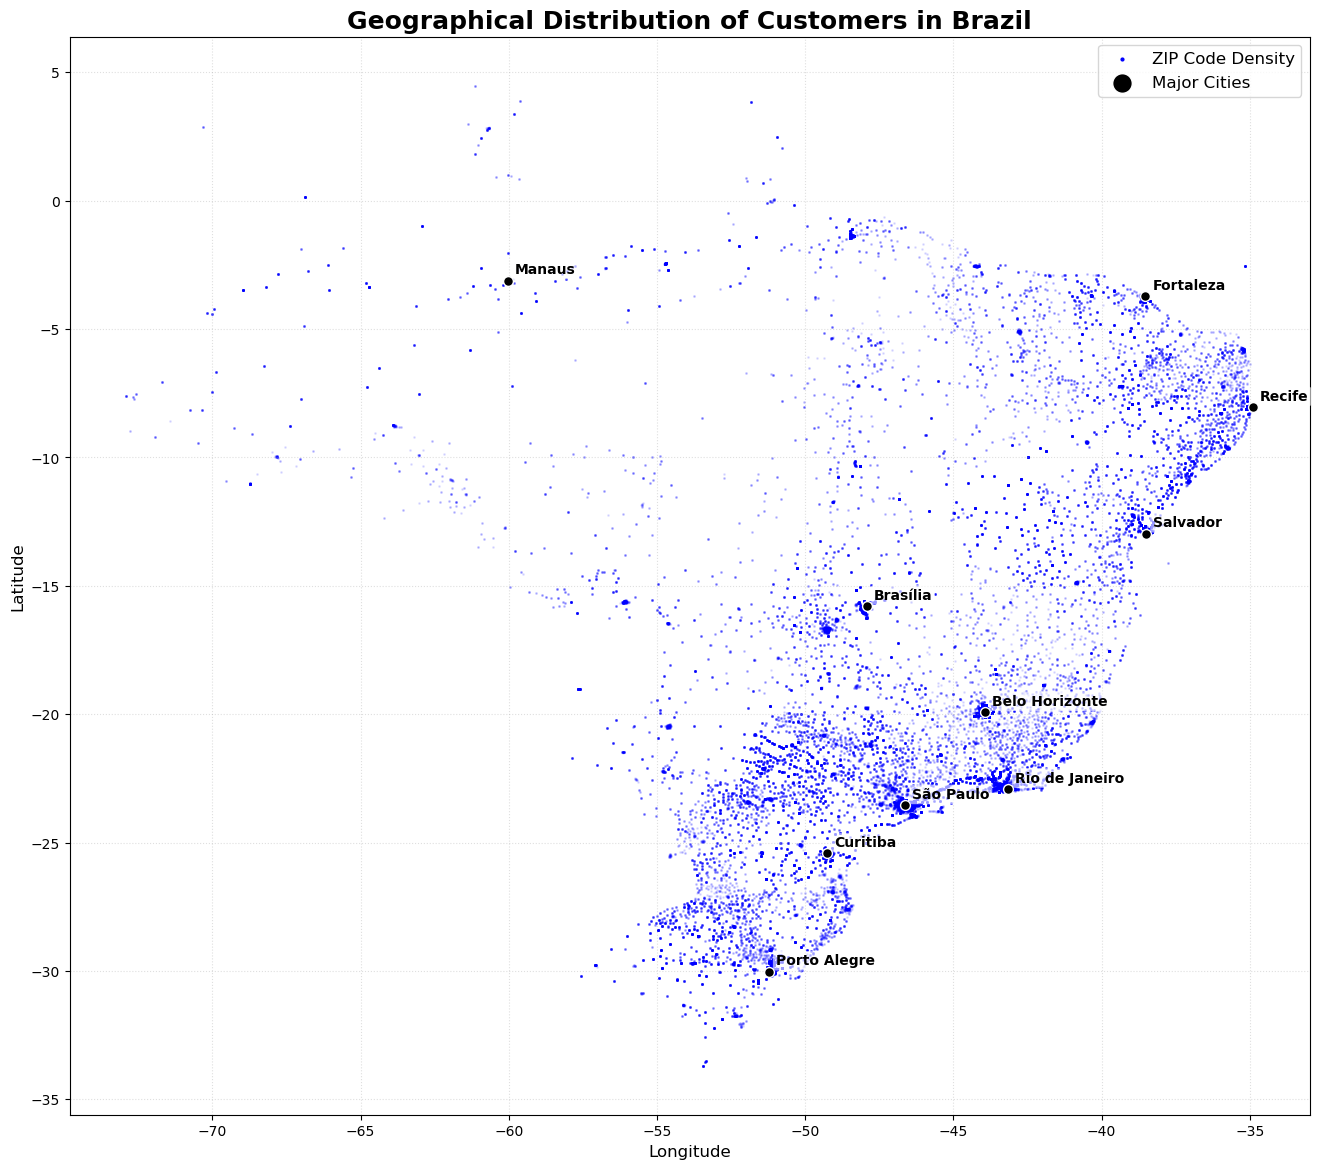

In [18]:
# Define major city coordinates for geographical reference
major_cities = {
    'São Paulo': (-23.55, -46.63), 'Rio de Janeiro': (-22.91, -43.17),
    'Brasília': (-15.78, -47.93), 'Salvador': (-12.97, -38.50),
    'Fortaleza': (-3.72, -38.52), 'Belo Horizonte': (-19.92, -43.94),
    'Curitiba': (-25.42, -49.27), 'Manaus': (-3.11, -60.02),
    'Recife': (-8.05, -34.88), 'Porto Alegre': (-30.03, -51.23)
}

plt.figure(figsize=(16, 14))

# Layer 1: ZIP Code density visualization
geo_plot_df = geolocation_ref[
    (geolocation_ref['geolocation_lat'] <= 5) & (geolocation_ref['geolocation_lat'] >= -35) &
    (geolocation_ref['geolocation_lng'] <= -35) & (geolocation_ref['geolocation_lng'] >= -75)
]

plt.scatter(
    geo_plot_df['geolocation_lng'], 
    geo_plot_df['geolocation_lat'], 
    alpha=0.1, s=1, c='blue', label='ZIP Code Density'
)

# Layer 2: Major city markers and annotations
is_first_entry = True
for city, coords in major_cities.items():
    lat, lng = coords
    legend_label = 'Major Cities' if is_first_entry else ""
    
    # Plot marker
    plt.scatter(lng, lat, c='black', s=50, edgecolors='white', zorder=5, label=legend_label)
    
    # Add city labels with styled background boxes
    plt.annotate(
        city, 
        xy=(lng, lat), 
        xytext=(5, 5), 
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        color='black',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'),
        zorder=6
    )
    is_first_entry = False

# Aesthetic configuration
plt.title('Geographical Distribution of Customers in Brazil', fontsize=18, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.4)

# Legend configuration with alpha correction
main_legend = plt.legend(markerscale=2, fontsize=12, loc='upper right', frameon=True)

# Force legend markers to be fully opaque for visibility
for handler in main_legend.legend_handles: 
    handler.set_alpha(1)

plt.show()

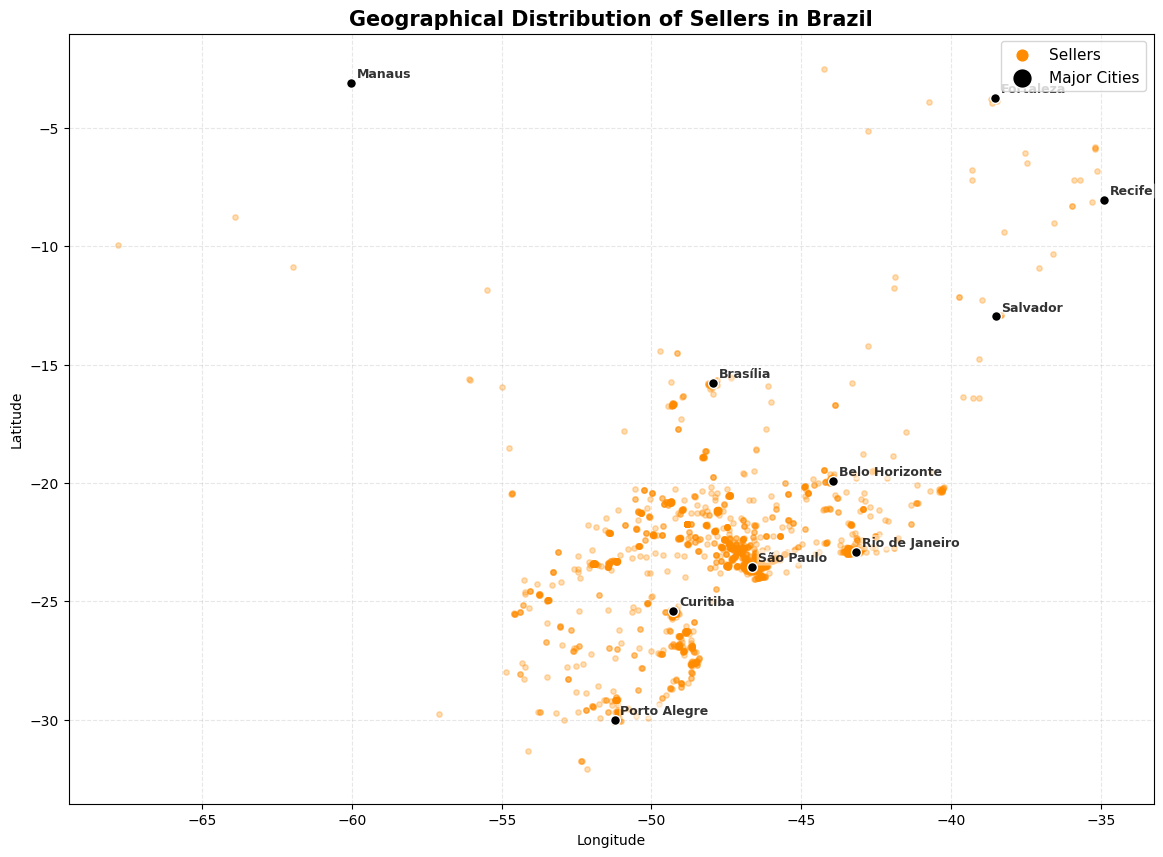

Total mapped sellers: 3088


In [19]:
# Load and process seller geographic data
sellers_data = pd.read_csv(os.path.join(dataset_path, "olist_sellers_dataset.csv"))
seller_geo_df = sellers_data.drop(['seller_city', 'seller_state'], axis=1)
seller_geo_df = pd.merge(seller_geo_df, geolocation_ref, left_on='seller_zip_code_prefix', right_index=True)
seller_geo_df = seller_geo_df.drop(['seller_zip_code_prefix'], axis=1)

# Plot Configuration
plt.figure(figsize=(14, 10))

# Layer 1: Seller distribution density (Orange)
plt.scatter(
    seller_geo_df['geolocation_lng'], 
    seller_geo_df['geolocation_lat'], 
    alpha=0.3, 
    s=15, 
    c='darkorange', 
    label='Sellers'
)

# Layer 2: Major Cities for reference
major_cities = {
    'São Paulo': (-23.55, -46.63), 'Rio de Janeiro': (-22.91, -43.17),
    'Brasília': (-15.78, -47.93), 'Salvador': (-12.97, -38.50),
    'Fortaleza': (-3.72, -38.52), 'Belo Horizonte': (-19.92, -43.94),
    'Curitiba': (-25.42, -49.27), 'Manaus': (-3.11, -60.02),
    'Recife': (-8.05, -34.88), 'Porto Alegre': (-30.03, -51.23)
}

# Iterate through cities to plot markers and labels
is_first_city = True
for city, coords in major_cities.items():
    lat, lng = coords
    legend_label = 'Major Cities' if is_first_city else ""
    
    # Plot city marker
    plt.scatter(lng, lat, c='black', s=50, edgecolors='white', zorder=5, label=legend_label)
    
    # Add city annotation
    plt.annotate(
        city, 
        xy=(lng, lat), 
        xytext=(4, 4), 
        textcoords='offset points', 
        fontsize=9, 
        fontweight='bold', 
        alpha=0.8,
        bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, ec='none')
    )
    is_first_city = False

# Aesthetics and Visual Consistency
plt.title('Geographical Distribution of Sellers in Brazil', fontsize=15, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.3)

# Manage legend visibility
main_legend = plt.legend(markerscale=2, fontsize=11, loc='upper right', frameon=True)

# Correct icon transparency in the legend for better legibility
for handler in main_legend.legend_handles: 
    handler.set_alpha(1)

plt.show()

# Operational summary
print(f"Total mapped sellers: {len(seller_geo_df)}")

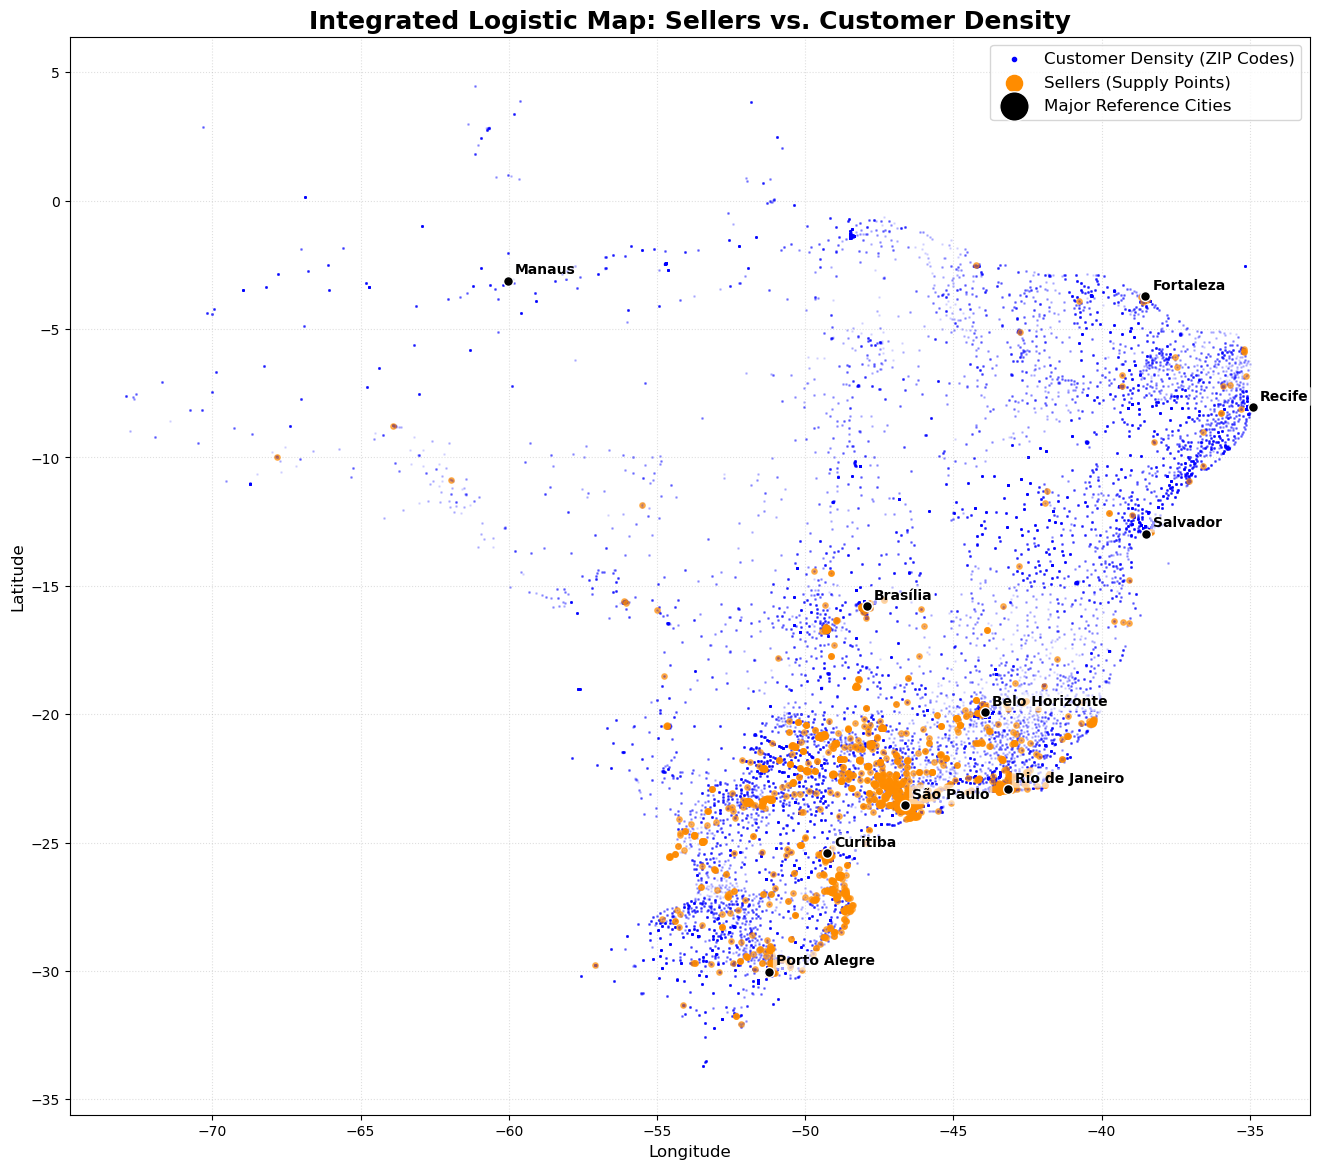

In [20]:
# Data Preparation: Apply coordinate filtering for geographic accuracy
customer_geo_filtered = geolocation_ref[
    (geolocation_ref['geolocation_lat'] <= 5) & (geolocation_ref['geolocation_lat'] >= -35) &
    (geolocation_ref['geolocation_lng'] <= -35) & (geolocation_ref['geolocation_lng'] >= -75)
]

plt.figure(figsize=(16, 14))

# Layer 1: Customer Density (Blue)
# Low alpha and small markers are used to visualize the "heat" of the market
plt.scatter(
    customer_geo_filtered['geolocation_lng'], 
    customer_geo_filtered['geolocation_lat'], 
    c='blue', 
    alpha=0.1, 
    s=1, 
    label='Customer Density (ZIP Codes)',
    zorder=1
)

# Layer 2: Seller Locations (Orange)
# Visualizing the distribution of shipping origins relative to customers
plt.scatter(
    seller_geo_df['geolocation_lng'], 
    seller_geo_df['geolocation_lat'], 
    c='darkorange', 
    alpha=0.6, 
    s=15, 
    label='Sellers (Supply Points)', 
    zorder=2
)

# Layer 3: Major Reference Cities (Black Markers)
major_cities = {
    'São Paulo': (-23.55, -46.63), 'Rio de Janeiro': (-22.91, -43.17),
    'Brasília': (-15.78, -47.93), 'Salvador': (-12.97, -38.50),
    'Fortaleza': (-3.72, -38.52), 'Belo Horizonte': (-19.92, -43.94),
    'Curitiba': (-25.42, -49.27), 'Manaus': (-3.11, -60.02),
    'Recife': (-8.05, -34.88), 'Porto Alegre': (-30.03, -51.23)
}

is_first_city = True
for city, coords in major_cities.items():
    lat, lng = coords
    legend_label = 'Major Reference Cities' if is_first_city else ""
    
    # Plot markers
    plt.scatter(lng, lat, c='black', s=50, edgecolors='white', zorder=5, label=legend_label)
    
    # Annotate city names with a stylized background box
    plt.annotate(
        city, 
        xy=(lng, lat), 
        xytext=(5, 5), 
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        color='black',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'),
        zorder=6
    )
    is_first_city = False

# Aesthetic and Legend Configuration
plt.title('Integrated Logistic Map: Sellers vs. Customer Density', fontsize=18, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.4)

main_legend = plt.legend(markerscale=3, fontsize=12, loc='upper right', frameon=True)

# Correct transparency in legend handles for better legibility
for handle in main_legend.legend_handles: 
    handle.set_alpha(1)

plt.show()